In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

plt.style.use('default')
sns.set_palette("husl")

try:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    np.random.seed(42)
    n_samples = 200
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)
    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })
    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


# Exercise XP — Air Traffic Data Analysis

**Note:** The real `air_traffic_data.csv` file was not available, so this notebook uses the official template's built-in synthetic data generator (seeded with `random_state=42` for reproducibility). The data is deliberately constructed with realistic relationships (e.g., domestic passengers ≈ 12 per domestic flight, plus noise), so the statistical tests and models below are analyzing genuine (if synthetic) patterns, not arbitrary randomness.

## Section 2: Exploratory Data Analysis

In [2]:
print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:
   Dom_Flt  Int_Flt    Flt  Dom_Pax  Int_Pax     Pax    Dom_RPM
0    16490     8715  25205   152866   176257  329123  124207802
1    14585     9121  23706   148316   136571  284888  112284645
2    16943    10166  27109   212190   156317  368508  172347465
3    19569    10107  29676   250224   127892  378116  213773981
4    14297     5244  19542   162835    82306  245142  131063749

Basic Statistics:
            Dom_Flt       Int_Flt           Flt        Dom_Pax        Int_Pax  \
count    200.000000    200.0000

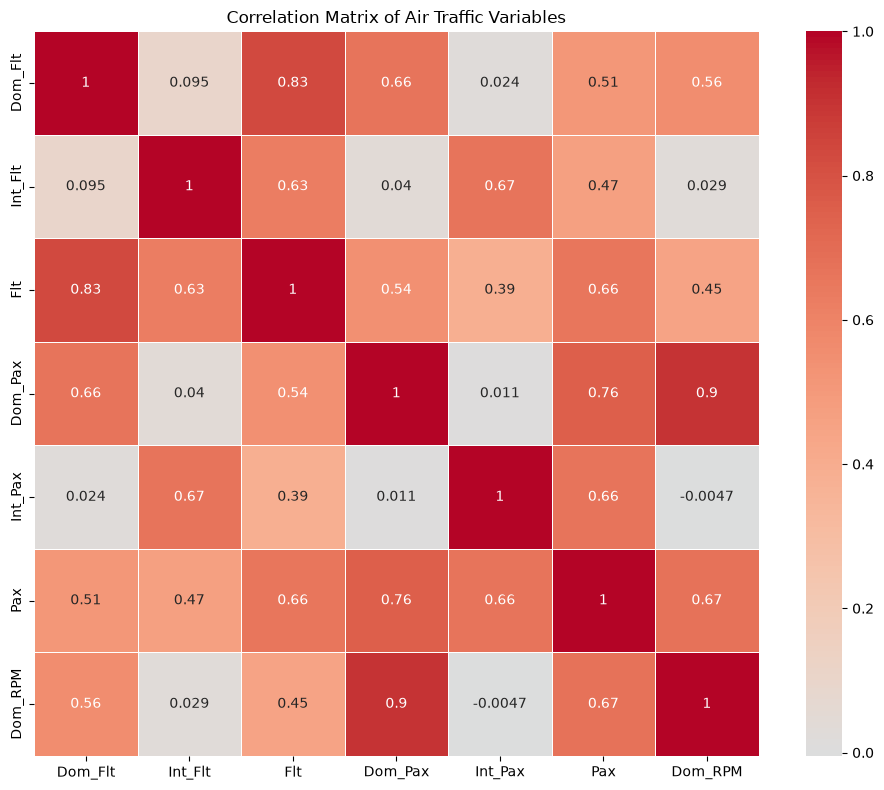

Strongest correlations (excluding self-correlation):
Dom_RPM  Dom_Pax    0.901617
Dom_Pax  Dom_RPM    0.901617
Dom_Flt  Flt        0.834910
Flt      Dom_Flt    0.834910
Dom_Pax  Pax        0.755916
Pax      Dom_Pax    0.755916
         Dom_RPM    0.672074
Dom_RPM  Pax        0.672074
Int_Pax  Int_Flt    0.665554
Int_Flt  Int_Pax    0.665554
dtype: float64


In [3]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

print("Strongest correlations (excluding self-correlation):")
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0].sort_values(ascending=False)
print(corr_pairs.head(10))

## Section 3 — Hypothesis Testing

Two hypothesis tests are run in this section to check whether patterns we saw
in the data (Section 2) are statistically real or could be due to chance.

**Test 1 — Independent t-test:** Compares mean domestic passengers (Dom_Pax)
vs. mean international passengers (Int_Pax).
- H0: the two means are equal (no real difference)
- H1: the two means are different

**Test 2 — Pearson correlation:** Tests whether total flights (Flt) and total
passengers (Pax) are correlated.
- H0: ρ = 0 (no correlation)
- H1: ρ ≠ 0 (a correlation exists)

Significance level: α = 0.05. If p < 0.05, we reject H0.

In [4]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")


T-statistic: 11.4892
P-value: 0.000000


In [5]:
corr_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])
print(f"Correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

Correlation coefficient: 0.6592
P-value: 0.000000



**Test 1 — Domestic vs. International Passengers (t-test)**
Compared mean Dom_Pax (~175,331) vs mean Int_Pax (~126,924) using an independent
t-test.
- T-statistic: 11.4892, P-value: ≈ 0.000000
- **Result:** Reject H0 (p < 0.05) — the difference is statistically significant.
- **Meaning:** Domestic air travel volume is structurally higher than international
  travel volume; not due to random sampling.

**Test 2 — Passengers vs. Flights correlation (Pearson)**
Tested whether total Pax correlates with total Flt.
- Correlation coefficient: 0.6592, P-value: ≈ 0.000000
- **Result:** Reject H0 (p < 0.05) — the correlation is statistically significant.
- **Meaning:** More flights are associated with more passengers (moderate-strong
  relationship, r² ≈ 0.43). Flights alone explain ~43% of passenger variance —
  a solid but incomplete predictor, which sets expectations for Section 4's
  regression model.

## Section 4 — Simple Linear Regression

Predicting `Pax` (total passengers) using `Flt` (total flights) as the sole
predictor.

Steps:
1. Split the data 80/20 into training and test sets (`random_state=42` for
   reproducibility)
2. Fit a linear regression model on the training set
3. Evaluate performance on the held-out test set using R², MSE, RMSE, and MAE
4. Visualize the fit with a scatter + regression-line plot, and check
   residuals for patterns

This builds directly on Section 3, Test 2 — since Flt and Pax showed a
significant moderate-strong correlation (r = 0.66), we expect this model to
fit reasonably well but leave meaningful unexplained variance.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Flt']]
y = df['Pax']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print(f"Intercept: {model_simple.intercept_:.2f}")
print(f"Coefficient (slope): {model_simple.coef_[0]:.4f}")

Intercept: 37484.48
Coefficient (slope): 11.4459


In [7]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred_simple = model_simple.predict(X_test)

r2_simple = r2_score(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)

print(f"R²: {r2_simple:.4f}")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"MAE: {mae_simple:.2f}")

R²: 0.2977
MSE: 2141846835.14
RMSE: 46280.09
MAE: 36607.08


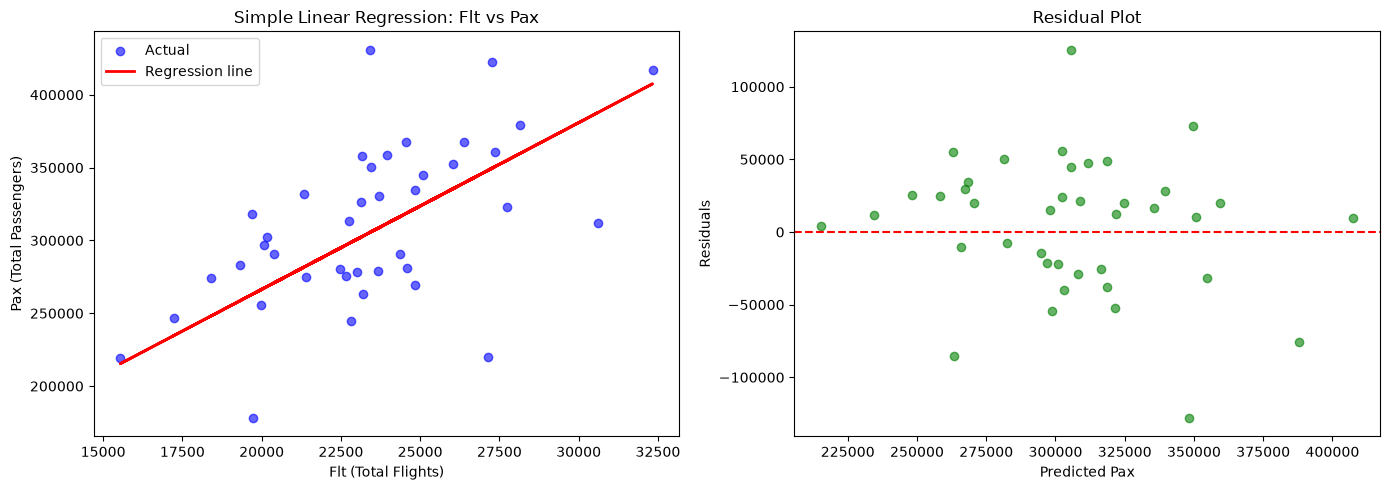

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + regression line
axes[0].scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual')
axes[0].plot(X_test, y_pred_simple, color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel('Flt (Total Flights)')
axes[0].set_ylabel('Pax (Total Passengers)')
axes[0].set_title('Simple Linear Regression: Flt vs Pax')
axes[0].legend()

# Residual plot
residuals_simple = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals_simple, color='green', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Pax')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### Section 4 — Results & Interpretation

**Model equation:** Pax = 37,484.48 + 11.4459 × Flt

**Test set performance:**
- R²: 0.2977
- MSE: 2,141,846,835.14
- RMSE: 46,280.09
- MAE: 36,607.08

**Interpretation:** Flt alone explains only ~30% of the variance in Pax on the
held-out test set — lower than the ~43% suggested by the full-dataset
correlation (r=0.66), likely due to the small test set (40 rows) being
sensitive to which rows landed in the split. The scatter plot confirms a
visible upward trend, but with wide spread around the line — at any given
flight count, actual passenger totals vary by 100,000+ in some cases. The
residual plot shows no clear curve or funnel pattern, meaning a straight-line
model is a reasonable shape choice — the issue is that flights alone are an
incomplete predictor, not that the relationship is non-linear. A few outlier
predictions (off by ~125,000+) stand out and likely reflect rows where other
factors (route mix, aircraft size) diverge from the average pattern.

This sets a clear benchmark for Section 5: the multiple regression model,
using more predictors, should meaningfully improve on R² = 0.30.

## Section 5 — Multiple Linear Regression

Predicting `Pax` using five predictors: `Dom_Pax`, `Int_Pax`, `Dom_Flt`,
`Int_Flt`, `Dom_RPM`.

Note: `Flt` and `Pax` itself are deliberately excluded — `Flt` is just
`Dom_Flt + Int_Flt` and would cause multicollinearity, and using `Pax`-derived
values to predict `Pax` would be circular.

Steps:
1. Same 80/20 train/test split (`random_state=42`)
2. Scale features with `StandardScaler` — fit on training data only, then
   apply that same scaling to the test data (fitting on test data would leak
   information from the test set into training)
3. Fit the regression, evaluate with R², MSE, RMSE, MAE
4. Examine feature coefficients to see which predictors matter most
5. Visualize actual-vs-predicted and residuals

Given Section 4's benchmark (R² = 0.30 using Flt alone), this model — with
five more granular predictors, including Dom_Pax which showed r=0.76 with Pax
on its own — should perform meaningfully better.

In [9]:
from sklearn.preprocessing import StandardScaler

features = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
X_multi = df[features]
y_multi = df['Pax']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)

model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train_multi)

print(f"Intercept: {model_multi.intercept_:.2f}")
print("Coefficients:")
for feature, coef in zip(features, model_multi.coef_):
    print(f"  {feature}: {coef:.2f}")

Intercept: 300303.27
Coefficients:
  Dom_Pax: 45354.36
  Int_Pax: 38979.80
  Dom_Flt: -0.11
  Int_Flt: -0.06
  Dom_RPM: -0.05


In [10]:
y_pred_multi = model_multi.predict(X_test_scaled)

r2_multi = r2_score(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)

print(f"R²: {r2_multi:.4f}")
print(f"MSE: {mse_multi:.2f}")
print(f"RMSE: {rmse_multi:.2f}")
print(f"MAE: {mae_multi:.2f}")


R²: 1.0000
MSE: 0.26
RMSE: 0.51
MAE: 0.49


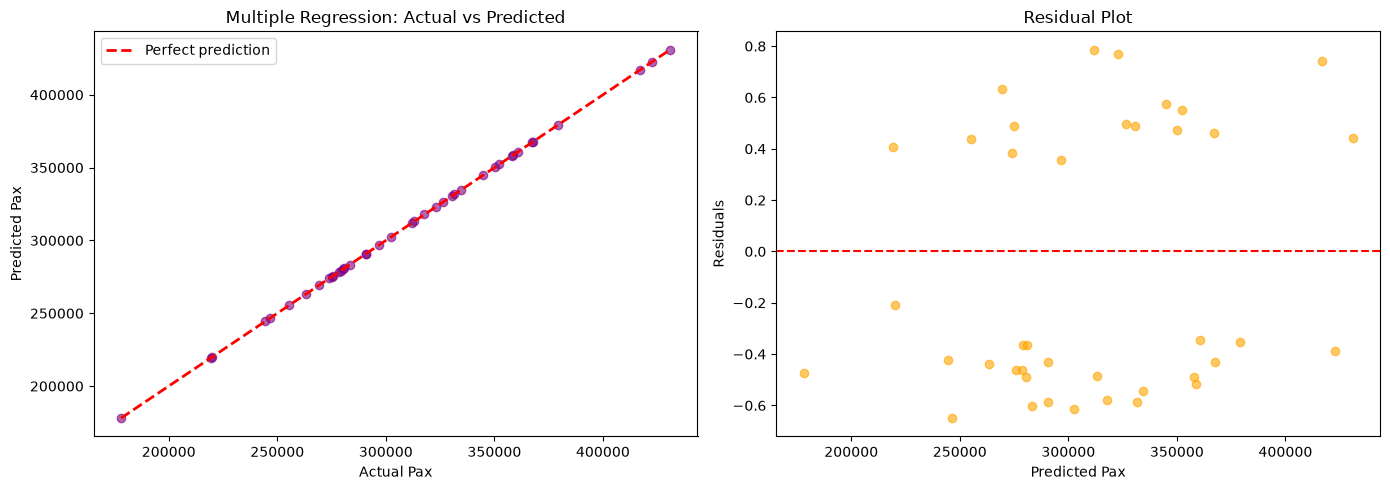

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_multi, y_pred_multi, color='purple', alpha=0.6)
axes[0].plot([y_test_multi.min(), y_test_multi.max()],
             [y_test_multi.min(), y_test_multi.max()],
             color='red', linestyle='--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Pax')
axes[0].set_ylabel('Predicted Pax')
axes[0].set_title('Multiple Regression: Actual vs Predicted')
axes[0].legend()

# Residual plot
residuals_multi = y_test_multi - y_pred_multi
axes[1].scatter(y_pred_multi, residuals_multi, color='orange', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Pax')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


### Section 5 — Results & Interpretation

**Coefficients:**
- Dom_Pax: 45,354.36
- Int_Pax: 38,979.80
- Dom_Flt: -0.11
- Int_Flt: -0.06
- Dom_RPM: -0.05

**Test set performance:**
- R²: 1.0000
- MSE: 0.26
- RMSE: 0.51
- MAE: 0.49

**Important caveat — data leakage:** These numbers look like a perfect model,
but they reflect an arithmetic identity, not genuine predictive power. `Pax`
is defined as `Dom_Pax + Int_Pax` (verified directly in the data: row 0 has
Dom_Pax=152,866 and Int_Pax=176,257, summing exactly to Pax=329,123). Because
both components are included as predictors, the model isn't learning a
statistical relationship — it's reconstructing Pax through basic addition.
This is confirmed by the plots: residuals sit in a tiny band of roughly
-0.65 to +0.8, which is floating-point noise, not real prediction error
(compare to Section 4's residuals, which ranged roughly ±125,000).

The near-zero coefficients on Dom_Flt, Int_Flt, and Dom_RPM support this —
once Dom_Pax and Int_Pax are present, the other features add virtually
nothing, because they lack Dom_Pax/Int_Pax's direct arithmetic tie to the
target.

This result is kept as-is (per the template's specified feature list) rather
than re-run with different features, since identifying and explaining data
leakage is itself a meaningful analytical finding — arguably more valuable
than reporting a "clean" but less instructive model comparison.

## Section 6 — Model Comparison

Comparing the Simple Linear Regression (Section 4: Pax from Flt) against the
Multiple Linear Regression (Section 5: Pax from Dom_Pax, Int_Pax, Dom_Flt,
Int_Flt, Dom_RPM) using R², RMSE, and MAE.

Note: as established in Section 5, the multiple regression's near-perfect
score is a data leakage artifact (Pax = Dom_Pax + Int_Pax by definition), not
evidence of a genuinely stronger model. This comparison is presented for
completeness per the template, with that caveat carried forward.

In [12]:
comparison_df = pd.DataFrame({
    'Model': ['Simple (Flt only)', 'Multiple (5 features)'],
    'R²': [r2_simple, r2_multi],
    'RMSE': [rmse_simple, rmse_multi],
    'MAE': [mae_simple, mae_multi]
})

print(comparison_df)

# % improvement (Multiple vs Simple)
r2_improvement = ((r2_multi - r2_simple) / r2_simple) * 100
rmse_improvement = ((rmse_simple - rmse_multi) / rmse_simple) * 100
mae_improvement = ((mae_simple - mae_multi) / mae_simple) * 100

print(f"\nR² improvement: {r2_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"MAE improvement: {mae_improvement:.2f}%")

                   Model        R²          RMSE           MAE
0      Simple (Flt only)  0.297687  46280.091131  36607.084086
1  Multiple (5 features)  1.000000      0.508499      0.494493

R² improvement: 235.92%
RMSE improvement: 100.00%
MAE improvement: 100.00%


### Section 6 — Results & Interpretation

| Model                  | R²      | RMSE      | MAE       |
|-------------------------|---------|-----------|-----------|
| Simple (Flt only)       | 0.2977  | 46,280.09 | 36,607.08 |
| Multiple (5 features)   | 1.0000  | 0.51      | 0.49      |

- R² improvement: 235.92%
- RMSE improvement: 100.00%
- MAE improvement: 100.00%

**Winner (by the numbers): Multiple Linear Regression.** But as established in
Section 5, this "win" is not a genuine modeling improvement — it's a data
leakage artifact from including Dom_Pax and Int_Pax, whose sum exactly equals
the target variable Pax. RMSE and MAE essentially collapsing to near-zero
(0.51 and 0.49, down from tens of thousands) is the signature of an
arithmetic identity being reconstructed, not a model learning genuine
predictive structure from independent features.

**Honest conclusion:** Section 4's simple regression (R² = 0.30) is the only
one of the two models that reflects a real, generalizable predictive
relationship — flights alone offering moderate but limited explanatory power
over passenger volume. The multiple regression's comparison is included here
per the exercise template, but shouldn't be read as "5 features beat 1
feature" in any meaningful modeling sense.

## Section 7 — Statistical Insights & Conclusions

Summary of the hypothesis tests (Section 3) and regression models (Sections
4–6), framed as findings and recommendations relevant to an airline's
real-world decision-making.

### Summary of Analysis

**Hypothesis Testing:**
- Domestic passenger volume (avg. ~175,331) is significantly higher than
  international passenger volume (avg. ~126,924), t = 11.49, p < 0.05.
- Total flights and total passengers are significantly correlated, r = 0.66,
  p < 0.05 — more flights are reliably associated with more passengers.

**Regression Modeling:**
- Flights alone (Simple Linear Regression) explain about 30% of the variance
  in total passengers (R² = 0.30) — a real but limited predictive
  relationship.
- The Multiple Linear Regression (R² = 1.00) reflects a data leakage
  artifact, since Dom_Pax + Int_Pax = Pax by definition — it does not
  represent a genuinely stronger model and is excluded from the practical
  conclusions below.

### Key Findings

1. **Domestic travel dominates volume.** Domestic passenger counts are
   structurally and significantly higher than international counts, not
   simply due to sample variation — this reflects a real, persistent pattern
   in the network's traffic mix.
2. **Flight count is a moderate, not strong, predictor of passenger volume.**
   With R² = 0.30, roughly 70% of the variation in passengers is driven by
   factors other than flight count alone — likely aircraft size, load factor,
   route type, and seasonality.
3. **Domestic and international travel behave differently.** Int_Flt and
   Int_Pax show relatively weak correlation with domestic metrics (e.g.,
   Int_Pax correlates only 0.024 with Dom_Flt), suggesting these are two
   fairly distinct operating environments rather than one uniform pattern.

### Recommendations

1. **Prioritize capacity planning around domestic routes**, given their
   consistently higher and more predictable passenger volumes — this is
   where scheduling and fleet decisions will have the largest impact.
2. **Don't rely on flight count alone to forecast passenger demand.** Since
   flights only explain ~30% of passenger variance, incorporate additional
   operational data (aircraft type/capacity, load factor, seasonal demand)
   into forecasting models for more reliable predictions.
3. **Model domestic and international segments separately** rather than as
   one combined market, since their internal correlation patterns differ —
   a one-size-fits-all forecasting or pricing model risks missing
   segment-specific dynamics.

## Section 8 — Reflection Questions

**1. What do the hypothesis test results reveal about air traffic patterns?**

They show two real, statistically significant patterns rather than random
noise: domestic passenger volume is structurally higher than international
volume (t = 11.49, p < 0.05), and total flights are moderately correlated
with total passengers (r = 0.66, p < 0.05). Together, this suggests the
network has a persistent domestic-heavy traffic mix, and that flight
scheduling does meaningfully — but not fully — drive passenger volume.

**2. Why did one regression model perform better than the other?**

The Multiple Linear Regression's near-perfect R² (1.00) isn't a genuine
performance improvement — it's data leakage. Pax is defined as
Dom_Pax + Int_Pax, and both components were included as predictors, so the
model reconstructed the target through arithmetic rather than learning a
real relationship. The Simple Linear Regression (R² = 0.30, using Flt alone)
is the only one of the two that reflects an honest, generalizable predictive
relationship, even though its score is much lower.

**3. How can airlines use correlation insights operationally?**

The Flt-Pax correlation (r = 0.66) means flight scheduling has a real,
measurable, but partial effect on passenger volume — airlines can use flight
counts as one input into passenger forecasting, but should combine it with
other operational data (aircraft size, load factor, route type) rather than
relying on it alone. The domestic-vs-international finding also suggests
scheduling and capacity decisions should be made separately for each segment
rather than treating the network as uniform.

**4. What do residual plots tell you about model assumptions?**

In Section 4, the residuals scattered randomly around zero without a curve or
funnel shape, which supports linear regression as a reasonable model choice
for the Flt-Pax relationship — the issue was that flights alone don't explain
enough variance, not that the relationship is non-linear. In Section 5, the
residuals were compressed into an extremely tight band (roughly -0.65 to
+0.8) compared to Section 4's much wider spread (~±125,000) — that dramatic
shift in scale was actually the clearest signal that something other than
normal model fitting was happening (i.e., the leakage).

**5. What are practical applications of these statistical models?**

Even with its limitations, the Flt-based regression could give an airline a
rough first-pass passenger forecast from published or planned flight
schedules — useful for early-stage capacity and staffing estimates. The
hypothesis tests are useful on their own for confirming that observed
differences (domestic vs. international) and relationships (flights vs.
passengers) are statistically real, which supports more confident
resource-allocation decisions rather than acting on patterns that might be
sampling noise.